In [12]:
#EXERCISE 1

from sklearn.model_selection import train_test_split 
import numpy as np
import matplotlib.pyplot as plt

X = np.random.randn(100, 3) * 5 + 35
y = 2*X[:,0] + X[:,1] - 0.5*X[:,2] + np.random.randn(100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,  random_state = 42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(80, 3)
(80,)
(20, 3)
(20,)


In [43]:
#EXERCISE 2

from sklearn.preprocessing import StandardScaler
temperature = np.random.uniform(30, 45, size = 100)
voltage = np.random.uniform(215, 225, size = 100)


X = np.column_stack((temperature, voltage))
y = temperature * 0.5 + voltage * 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,  random_state = 42)

scaler = StandardScaler() 
scaler.fit(X_train)
Xs = scaler.transform(X_train)
Xt = scaler.transform(X_test)

print(f"The mean of X_train before scaling is: {X_train.mean():.2f} and the std of X_test before scalling is: {X_train.std():.2f}")
print(f"The mean and std for X_train after scaling is: {Xs.mean():.2f} and {Xs.std():.2f}")

The mean of X_train before scaling is: 129.43 and the std of X_test before scalling is: 90.92
The mean and std for X_train after scaling is: 0.00 and 1.00


RMSE: 2.230521494950924
MAE : 1.7967080810572857
R²  : 0.9213671342494806
(240, 4)


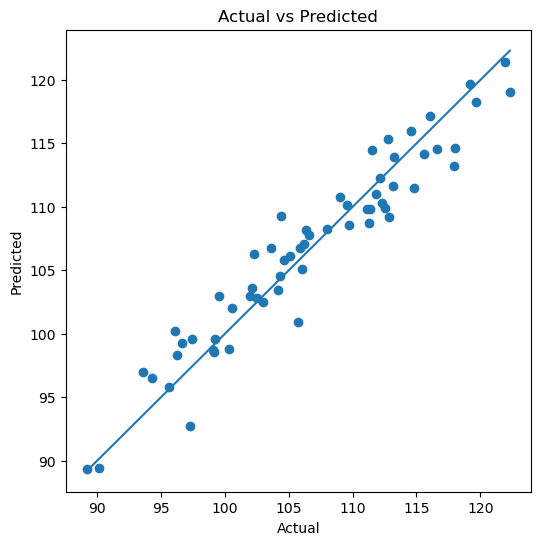

In [2]:
#EXERCISE 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

# -----------------------------
# (a) Generate dataset
# -----------------------------

np.random.seed(42)

n = 300

# Features stored as a dictionary
X_dict = {
    "hours_op": np.random.uniform(1, 12, n),
    "ambient": np.random.uniform(20, 40, n),
    "load_pct": np.random.uniform(40, 100, n),
    "voltage": np.random.uniform(210, 230, n)
}

# Convert dictionary to DataFrame
X = pd.DataFrame(X_dict)

# Target variable (physical formula + noise)
noise = np.random.normal(0, 2, n)

y = (
    30
    + 1.5 * X["hours_op"]
    + 0.8 * X["ambient"]
    + 0.3 * X["load_pct"]
    + 0.1 * X["voltage"]
    + noise
)

# -----------------------------
# (b) Split, scale, train
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LinearRegression()

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# -----------------------------
# (c) Evaluate model
# -----------------------------

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

# -----------------------------
# Scatter plot
# -----------------------------

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

print(X_train.shape)


plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()


The model coeficient is:  [4.77632955 4.82363715 5.32447925 0.82402087]
This model's intercept is:  106.49086225666369


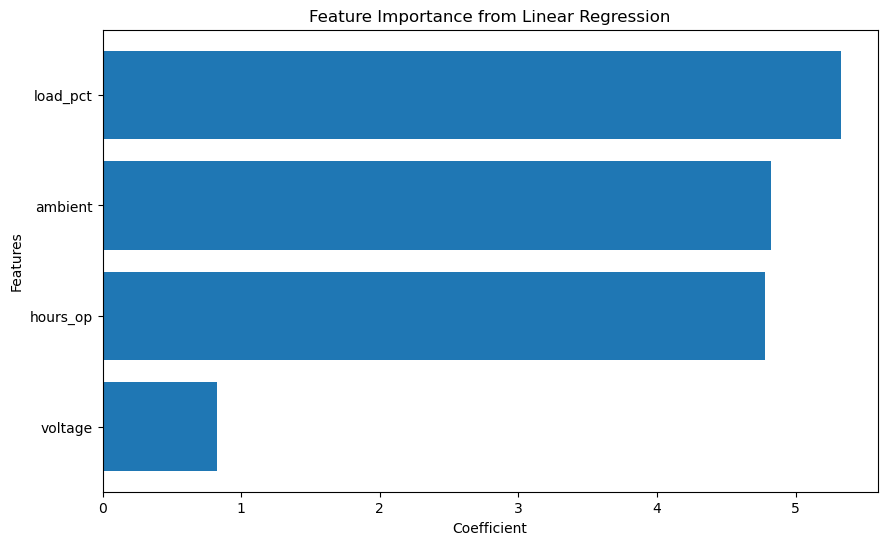

In [14]:
#EXERCISE 4

coefficient = model.coef_
print("The model coeficient is: ",coefficient)
intercept = model.intercept_
print("This model's intercept is: ",intercept)

feature_name = X.columns

sorted_coefs = sorted(zip(feature_name, coefficient), key = lambda x : abs(x[1]))

features = [x[0] for x in sorted_coefs]
coef_values = [x[1] for x in sorted_coefs]

plt.figure(figsize = (10, 6))
plt.barh(features, coef_values) 
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Importance from Linear Regression")


plt.show()




# the feature with the strongest positive influence on the winding temperature is hours_op because it has the largest positive coefficient in the formula used to generate the dataset.


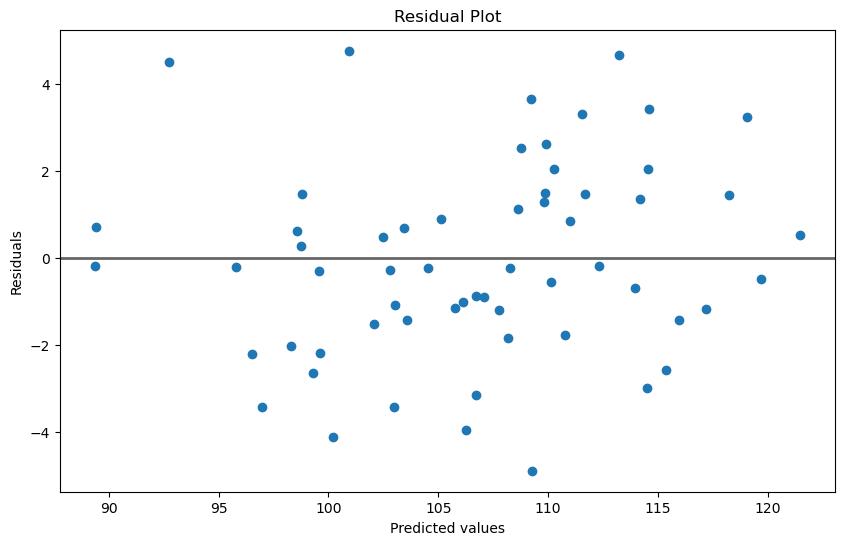

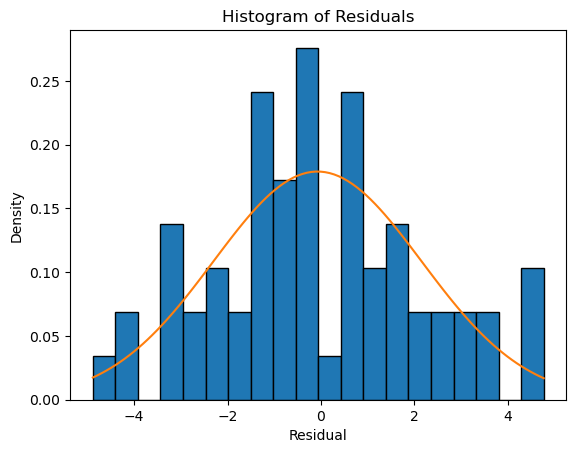

In [26]:
#EXERCISE 5

from scipy.stats import norm
# Y_test = np.array([y_test])
# Y_pred = np.array([y_pred])
residual = y_test - y_pred
# print(residual)

plt.figure(figsize = (10, 6))

plt.scatter(y_pred, residual)
# plt.plot([y_pred], [residual])
plt.axhline(y = 0, color="black", alpha=0.6, linewidth=2)

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# Histogram
plt.hist(residual, bins=20, density=True, edgecolor = "black")

# Gaussian overlay
mu = np.mean(residual)
sigma = np.std(residual)

x = np.linspace(residual.min(), residual.max(), 100)

plt.plot(x, norm.pdf(x, mu, sigma))

plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram of Residuals")

plt.show()

In [32]:
# EXERCISE 7

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R2 scores per fold:", scores)

print("Mean R2:", np.mean(scores))
print("Std R2:", np.std(scores))



poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_scores = cross_val_score(
    poly_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nPolynomial Degree 2 R2 scores:", poly_scores)
print("Mean R2:", np.mean(poly_scores))
print("Std R2:", np.std(poly_scores))

R2 scores per fold: [-15.59949472   0.48852216  -0.02640372   0.7113642   -1.0661236 ]
Mean R2: -3.09842713617484
Std R2: 6.28052532035753

Polynomial Degree 2 R2 scores: [0.64982648 0.84258552 0.93006824 0.9631109  0.95309403]
Mean R2: 0.8677370341256239
Std R2: 0.11694851697843721


Degree 1 RMSE: 3.986850006351357
Degree 2 RMSE: 1.4632073799459473
Degree 3 RMSE: 1.462907599001214


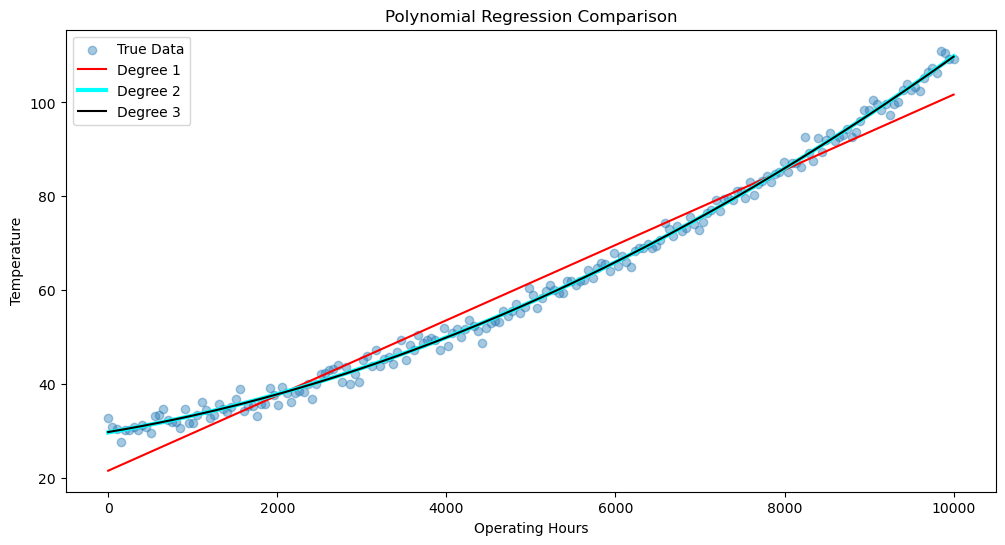

In [29]:
# EXERCISE 6

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# -----------------------------------
# (a) Generate dataset
# -----------------------------------

np.random.seed(3)

# Operating hours
X_1d = np.linspace(0, 10000, 200)

# Noise
noise = np.random.normal(0, 1.5, 200)

# Target variable
y = (
    30
    + 0.003 * X_1d
    + 5e-7 * X_1d**2
    + noise
)

# Reshape input
X = X_1d.reshape(-1, 1)

# -----------------------------------
# (b) Degree 1 (Linear Regression)
# -----------------------------------

linear_model = LinearRegression()

linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)

rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))

print("Degree 1 RMSE:", rmse_linear)

# -----------------------------------
# (c) Degree 2 Polynomial Regression
# -----------------------------------

poly2 = PolynomialFeatures(degree=2)

X_poly2 = poly2.fit_transform(X)

model_deg2 = LinearRegression()

model_deg2.fit(X_poly2, y)

y_pred_deg2 = model_deg2.predict(X_poly2)

rmse_deg2 = np.sqrt(mean_squared_error(y, y_pred_deg2))

print("Degree 2 RMSE:", rmse_deg2)

# -----------------------------------
# (d) Degree 3 Polynomial Regression
# -----------------------------------

poly3 = PolynomialFeatures(degree=3)

X_poly3 = poly3.fit_transform(X)

model_deg3 = LinearRegression()

model_deg3.fit(X_poly3, y)

y_pred_deg3 = model_deg3.predict(X_poly3)

rmse_deg3 = np.sqrt(mean_squared_error(y, y_pred_deg3))

print("Degree 3 RMSE:", rmse_deg3)

# -----------------------------------
# Plot all curves
# -----------------------------------

plt.figure(figsize=(12, 6))

# True data (optional)
plt.scatter(X, y, label="True Data", alpha=0.4)

# Degree 1 → RED
plt.plot(X, y_pred_linear, color="red", label="Degree 1")

# Degree 2 → CYAN
plt.plot(X, y_pred_deg2, color="cyan", linewidth = 3, label="Degree 2")

# Degree 3 → BLACK
plt.plot(X, y_pred_deg3, color="black", label="Degree 3")

plt.xlabel("Operating Hours")
plt.ylabel("Temperature")
plt.title("Polynomial Regression Comparison")

plt.legend()
plt.show()

In [41]:
# EXERCISE 8


np.random.seed(0)

n = 1000

X_dict = {
    "operating_hours" : np.random.uniform(1, 12, n),
    "ambient_temp" : np.random.uniform(20, 40, n),
    "load_percentage" : np.random.uniform(40, 100, n),
    "supply_voltage" : np.random.uniform(215, 225, n),
    "vibration_rms" : np.random.uniform(0.5, 8.0, n),
    "oil_viscosity" : np.random.uniform(20, 100, n)
}

X = pd.DataFrame(X_dict)

noise = np.random.normal(0, 10, n)

y = (
    500
    - 2.5 * X["load_percentage"]
    - 25 * X["vibration_rms"]
    - 1.2 * X["ambient_temp"]
    + 0.4 * X["oil_viscosity"]
    + noise
)
y = np.clip(y, 10, None)

X["power_factor"] = X["load_percentage"]/ X["supply_voltage"]
X["heat_index"] = (
    X["ambient_temp"]* X["load_percentage"]/100
)
X["wear_rate"] =( X["operating_hours"]* X["vibration_rms"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Linear Regression
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred))

print("Degree 1 RMSE:", rmse_linear)

#Degree 2: Polynomial Regression
poly2 = PolynomialFeatures(degree=2)

# Fit on training data
X_train_poly2 = poly2.fit_transform(X_train)

# Transform test data
X_test_poly2 = poly2.transform(X_test)

model_deg2 = LinearRegression()

model_deg2.fit(X_train_poly2, y_train)

y_pred_deg2 = model_deg2.predict(X_test_poly2)

rmse_deg2 = np.sqrt(
    mean_squared_error(y_test, y_pred_deg2)
)

print("Degree 2 RMSE:", rmse_deg2)

#Degree 2: Polynomial Regression
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)

X_test_poly3 = poly3.transform(X_test)

model_deg3 = LinearRegression()

model_deg3.fit(X_train_poly3, y_train)

y_pred_deg3 = model_deg3.predict(X_test_poly3)

rmse_deg3 = np.sqrt(
    mean_squared_error(y_test, y_pred_deg3)
)

print("Degree 3 RMSE:", rmse_deg3)


model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R2 scores per fold:", scores)

print("Mean R2:", np.mean(scores))
print("Std R2:", np.std(scores))



poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_scores = cross_val_score(
    poly_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nPolynomial Degree 2 R2 scores:", poly_scores)
print("Mean R2:", np.mean(poly_scores))
print("Std R2:", np.std(poly_scores))


##PLOTS
# plt.figure(figsize=(12, 6))

# # True data (optional)
# plt.scatter(X, y, label="True Data", alpha=0.4)

# # Degree 1 → RED
# plt.plot(X, y_pred_linear, color="red", label="Degree 1")

# # Degree 2 → CYAN
# plt.plot(X, y_pred_deg2, color="cyan", linewidth = 3, label="Degree 2")

# # Degree 3 → BLACK
# plt.plot(X, y_pred_deg3, color="black", label="Degree 3")

# plt.xlabel("Operating Hours")
# plt.ylabel("Temperature")
# plt.title("Polynomial Regression Comparison")

# plt.legend()
# plt.show()



Degree 1 RMSE: 9.650710099857527
Degree 2 RMSE: 10.014762121208168
Degree 3 RMSE: 11.805786175267762
R2 scores per fold: [0.97907568 0.976472   0.97876191 0.97912429 0.97946209]
Mean R2: 0.9785791939488757
Std R2: 0.0010767337022445102

Polynomial Degree 2 R2 scores: [0.97882932 0.97446229 0.97695541 0.97715352 0.9773933 ]
Mean R2: 0.9769587684068576
Std R2: 0.0014112508934468952


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from joblib import dump, load

# -----------------------------------
# Create best pipeline
# -----------------------------------

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("ridge", Ridge())
])

# Train
best_model.fit(X_train, y_train)

# -----------------------------------
# Save model
# -----------------------------------

dump(best_model, "predictive_maintenance_model.joblib")

# -----------------------------------
# Load model
# -----------------------------------

loaded_model = load("predictive_maintenance_model.joblib")

# -----------------------------------
# New unseen sample
# -----------------------------------

new_sample = pd.DataFrame({
    "operating_hours": [8],
    "ambient_temp": [35],
    "load_percentage": [80],
    "supply_voltage": [220],
    "vibration_rms": [5.5],
    "oil_viscosity": [60]
})

# Feature engineering
new_sample["power_factor"] = (
    new_sample["load_percentage"]
    / new_sample["supply_voltage"]
)

new_sample["heat_index"] = (
    new_sample["ambient_temp"]
    * new_sample["load_percentage"]
) / 100

new_sample["wear_rate"] = (
    new_sample["operating_hours"]
    * new_sample["vibration_rms"]
)

# Prediction
prediction = loaded_model.predict(new_sample)

print("Predicted Failure Time:", prediction[0])

Predicted Failure Time: 144.8644788038399
